# DSHI Homework 3 - Classification

**Name:** Iman Dashtpeyma

## Step 1: Dataset Loading
Load and inspect the dataset.

In [3]:
import pandas as pd
df = pd.read_csv('./data/combined_student_data.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,mat
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,mat
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,mat
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,mat
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,mat


## Step 2: Exploratory Data Analysis (EDA)
Numerical and visual analyses.

In [4]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


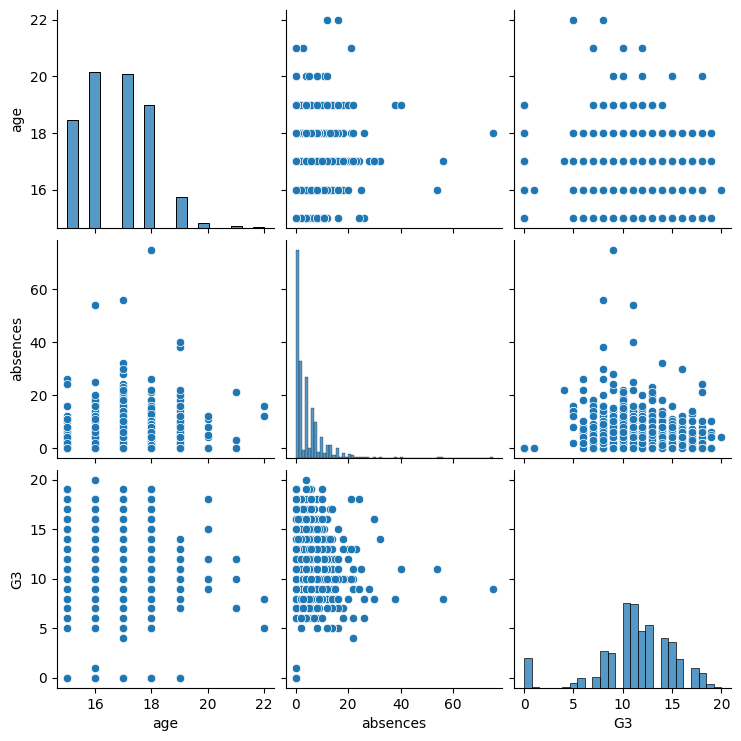

In [12]:
import seaborn as sns
sns.pairplot(df[['age', 'absences', 'G3']])

## Step 3: Data Preparation for Classification
Encode categorical variables and split dataset.

In [13]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

df['pass'] = df['G3'] >= 10

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_features = encoder.fit_transform(df[['sex', 'school', 'address']])

encoded_df = pd.DataFrame(
    encoded_features, 
    columns=encoder.get_feature_names_out(['sex', 'school', 'address'])
)

X = pd.concat([df[['age', 'absences']], encoded_df], axis=1)
y = df['pass'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)


(835, 5) (209, 5)


## Step 4: Classifier Evaluation
Evaluate multiple classifiers using cross-validation.

In [11]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate

classifiers = {
    'DT_depth3': DecisionTreeClassifier(max_depth=3),
    'DT_depth5': DecisionTreeClassifier(max_depth=5),
    'RF_10': RandomForestClassifier(n_estimators=10),
    'RF_50': RandomForestClassifier(n_estimators=50),
    'KNN_3': KNeighborsClassifier(n_neighbors=3),
    'KNN_7': KNeighborsClassifier(n_neighbors=7),
    'SVM_linear': SVC(kernel='linear'),
    'SVM_rbf': SVC(kernel='rbf'),
    'LogReg_01': LogisticRegression(C=0.01, max_iter=500),
    'GaussianNB': GaussianNB()
}

results = {}
for name, clf in classifiers.items():
    scores = cross_validate(clf, X_train, y_train, cv=5,
                            scoring=['accuracy', 'precision', 'recall', 'f1'],
                            n_jobs=-1)
    results[name] = {
        'accuracy': scores['test_accuracy'].mean(),
        'precision': scores['test_precision'].mean(),
        'recall': scores['test_recall'].mean(),
        'f1_score': scores['test_f1'].mean()
    }

pd.DataFrame(results).T.sort_values(by='f1_score', ascending=False)


,accuracy,precision,recall,f1_score
SVM_linear,0.779641,0.779641,1.000000,0.876176
SVM_rbf,0.779641,0.779641,1.000000,0.876176
LogReg_01,0.779641,0.780987,0.996923,0.875838
DT_depth3,0.777246,0.792528,0.967728,0.871377
GaussianNB,0.772455,0.794383,0.955420,0.867464
DT_depth5,0.760479,0.791802,0.940070,0.859531
KNN_7,0.755689,0.786225,0.943147,0.857542
KNN_3,0.729341,0.787562,0.893964,0.837201
RF_10,0.710180,0.785154,0.864756,0.822829
RF_50,0.707784,0.780651,0.869419,0.822251


## Step 5: Conclusion
Reflect on the best classifier and its suitability for deployment.